# Day 18

I will start with what I missed yesterday:

## Correlation Functions:

Correlation functions characterise how the distribution of points differ from a random distribution.

For example, if two galaxies are clustered together, they are correlated.

### Two point correlation function

We can define a correlation function by denoting the probability of finding a point in a volume element, dV. It is directly proportional to the density of points $\rho$. Hence the probability of finding a pair of points in two volume elements, $dV_1$ and $dV_2$, separated by a distance, $r$ is:

$$dP_{12} = \rho^2 dV_1 dV_2 (1 + \xi(r))$$

Where $\xi(r)$ is known as the two point correlation function. And is an excess, due to there being more galaxies near other galaxies than you'd expect from purely random distribution.

Hence we can see that the two point correlation function describes the excess probability of finding a pair of points, as a function of separation, compared to a random distribution.

Positive, negative and 0 amplitudes in $\xi(r)$ correspond to distributions that are correlated, anticorrelated or random respectively.

### Density of fluctuations

The correlation function can be used to describe the density of fluctuations by:

$$\xi(r) = \left\langle \frac{\delta\rho(x)}{\rho} \frac{\delta\rho(x + r)}{\rho} \right\rangle$$

Where $\delta \rho(x) / \rho = (\rho - \bar{\rho}) / \rho$ is the density contrast relative to the mean value $\bar{\rho}$ at position $x$

### Power spectrum

The two point correlation function directly relates to the power spectrum through the fourier transform:

$$\xi(r) = \frac{1}{2\pi^2} \int dk \, k^2 P(k) \frac{\sin(kr)}{kr}$$

### Angular correlation function

We usually wish to not use a 3D correlation function, but an angular correlation function of the apparent positions of objects on the sky.

The approximate form for the relation is:

$$w(\theta) = \left( \frac{\theta}{\theta_0} \right)^\delta$$

with $\delta = 1 - \gamma$

### n-point correlation functions

We can use n-point correlation functions but the 2 point function is most common as when we are dealing with large populations of sources spread across the Universe, we can use the central limit theorem to motivate why the density field can often be approximated as Gaussian. Hence correlations can be approximated as obeying Gaussian statistics, which are entirely defined by the mean and two point correlators.

A good [link](https://www.youtube.com/watch?v=cTUVzoYDztU)

We will look at coding this later!

---

## Lecture 15 - dimensionality

### Curse of dimensionality

When we wish to analyse and organise data in high dimensions, we often have a curse that arises when the number of data points is small relative to the intrinsic dimensions of the data.

As the number of dimensions increases, the volume increases very fast such that the available data becomes sparese. Usually, we need the data to grow exponentially with the dimensionality.

This can be expressed when we wish to find a certain car. If you wish for it to be diesel, modern, have a sunroof, certain type of body, brand etc, the probability of finding the car in a dealership gets smaller and smaller, even if all of these had a 50% chance of occuring, then the chance of finding it would be $p = 0.5^5 = 0.03125$ which isn't very good.

Mathematically the way to describe this is that the more dimensions are data spans, the more points are needed to uniformly sample the space

### PCA

We already have used this but lets actually look at it:

We can usually plot 1-3 dimensions normally, and interpet it as we usually would. But when it comes to 4 or more dimensions, we can no longer plot it in an intuitive way.

Hence, we need to use PCA to take 4 dimensions and reduce them down into 2.

#### Say we have 2 dimensions

We have some data, such that it is 2 features that can be plotted on a feature against feature 2D graph.

PCA will find the line that goes through the origin that maximises the sum of the squared distances from the projected points to the origin. Where projecting a point means to take the shortest distance to place that point on the line.

The following example assumes the two features are Genes, and it shows how the points are projected. Then we square the points and add them up

It is a beautiful video from [StatQuest](https://www.youtube.com/watch?v=FgakZw6K1QQ&t=2s)

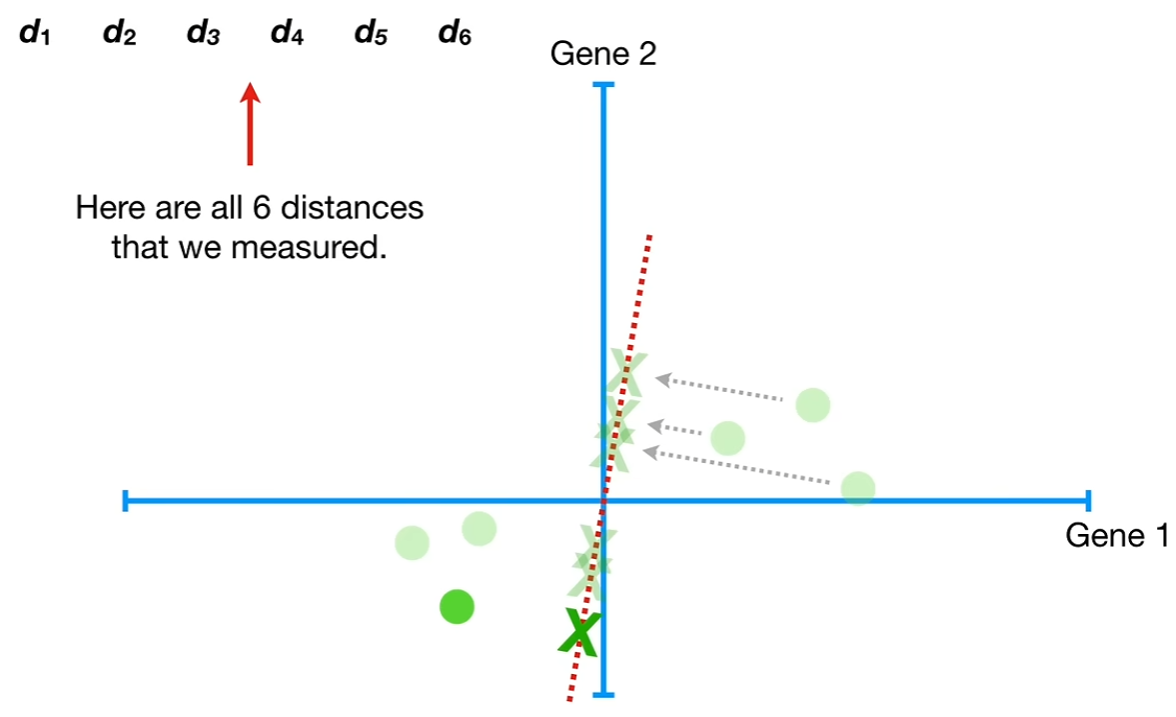

The line is then rotated and the same happens until we find the largest sum of the squared distances between the projected points and the origin

The line that we end up finding is called Principle component one, or PC1.

If we get a gradient for this line as 0.25. Then the data is clearly spread along the Gene 1 axis, as when moving 1 point up along the Gene 2 axis, we move 4 points across the Gene 1 axis.

We can find a unit vector along PC1, by using this fact:

$$4^2 + 1^2 = 17^2 \rightarrow 4.12 $$

But since it is a unit vector we divide all 3 sides by 4.12 to give us the unit vector.

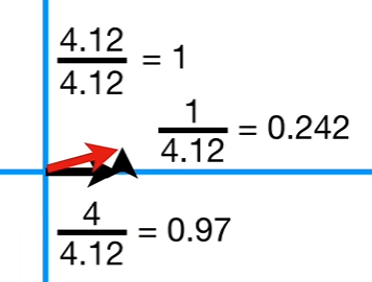

This 1 unit long vector is called the eigenvector, and the proportions for each gene are called loading scores.

PC2 is perpendicular to PC1. So the eigenvector will consist of -0.242 units along Gene 1 and 0.97 units along Gene 2. To note these are our loading scores.

### So more mathematically

So more mathematically, PCA allows us to take a datset and apply a transform on the data such that the new axes are aligned with the maximum variance of the data.

### Ivezic example

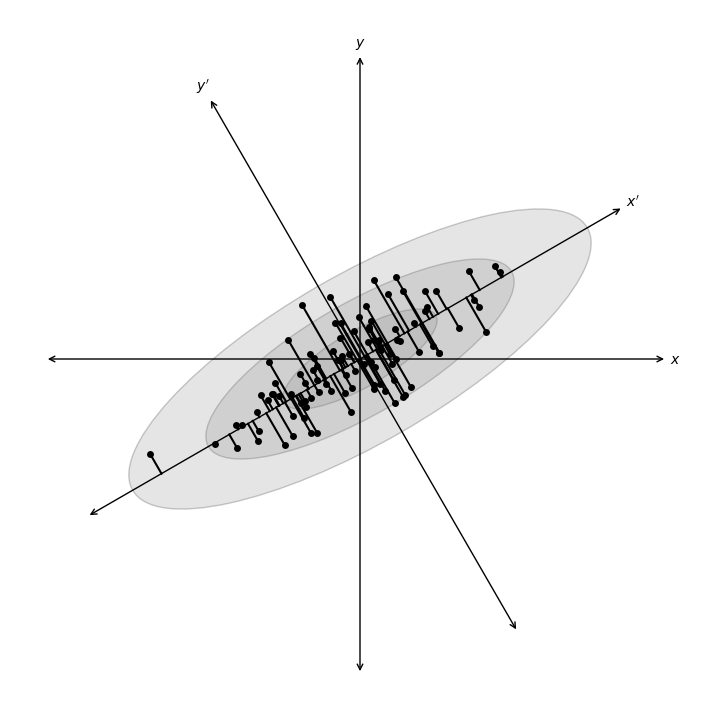

In [1]:
import numpy as np
from matplotlib import pyplot as plt
# Execute this cell
# Ivezic, Figure 7.2
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from matplotlib.patches import Ellipse

#------------------------------------------------------------
# Set parameters and draw the random sample
np.random.seed(42)
r = 0.9

sigma1 = 0.25
sigma2 = 0.08
rotation = np.pi / 6
s = np.sin(rotation)
c = np.cos(rotation)

X = np.random.normal(0, [sigma1, sigma2], size=(100, 2)).T
R = np.array([[c, -s],[s, c]])
X = np.dot(R, X) #Same data, now rotated by R matrix.

#------------------------------------------------------------
# Plot the diagram
fig = plt.figure(figsize=(7, 7), facecolor='w')
ax = plt.axes((0, 0, 1, 1), xticks=[], yticks=[], frameon=False)

# draw axes
ax.annotate(r'$x$', (-r, 0), (r, 0),
            ha='center', va='center',
            arrowprops=dict(arrowstyle='<->', 
                            color='k', lw=1))
ax.annotate(r'$y$', (0, -r), (0, r),
            ha='center', va='center',
            arrowprops=dict(arrowstyle='<->', 
                            color='k', lw=1))

# draw rotated axes
ax.annotate(r'$x^\prime$', (-r * c, -r * s), (r * c, r * s),
            ha='center', va='center',
            arrowprops=dict(color='k', 
                            arrowstyle='<->', 
                            lw=1))
ax.annotate(r'$y^\prime$', (r * s, -r * c), (-r * s, r * c),
            ha='center', va='center',
            arrowprops=dict(color='k', 
                            arrowstyle='<->', 
                            lw=1))

# scatter points
ax.scatter(X[0], X[1], s=25, 
           lw=0, c='k', zorder=2)

# draw lines
vnorm = np.array([s, -c])
for v in (X.T):
    d = np.dot(v, vnorm)
    v1 = v - d * vnorm
    ax.plot([v[0], v1[0]], [v[1], v1[1]], '-k')

# draw ellipses
for sigma in (1, 2, 3):
    ax.add_patch(Ellipse((0, 0),
                         2 * sigma * sigma1,
                         2 * sigma * sigma2,
                         angle=rotation * 180. / np.pi,
                         ec='k', fc='gray', alpha=0.2, zorder=1))

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

plt.show()


We can see that the points are correlated along an axis that wasn't our initial choice, so we should rotate our axes  to align with the correlation.

1. The first axis, or principal component is the direction of maximal variance
2. the second component is orthogonal to the first and maximises the residual variance.

### Preparing for PCA

How do we prepare our data for PCA?

1. Subtract the mean of each dimension/feature/column (all mean the same thing) to centre the data around 0.
2. Divide by the variance in each dimension/feature/column to standardise the scale across different features
3. Normalise each sample/row so that each row yields an integral of unity.



Below is a typical call to the PCA algorithm.

In [2]:
#Example call from 7.3.2 slightly changed for better terminology
import numpy as np
from sklearn.decomposition import PCA

X = np.random.normal(size=(100, 3)) # 100 points in 3D
R = np.random.random((3, 10)) # projection matrix
X = np.dot(X, R) # X is now 10-dim, with 3 intrinsic dims

pca = PCA(n_components=4) # n_components can be optionally set
pca.fit(X)

scores = pca.transform(X) # compute the subspace projection of X, 4 PCA scores for each of the 100 samples
mean = pca.mean_ # length 10 mean of the data
eigenvectors = pca.components_ # 4x10 matrix of components, multiply each by respective PCA score to reconstruct

# Reconstruction of object1
# Xreconstruct[0] = mean + eigenvectors * scores[0]

print(scores.shape)
print(eigenvectors.shape)

(100, 4)
(4, 10)


In [3]:
# Example from Andy Connolly
# See Ivezic, Figure 7.4

from sklearn.decomposition import PCA
#from sklearn.decomposition import RandomizedPCA

from astroML.datasets import sdss_corrected_spectra
from astroML.utils import pickle_results

#------------------------------------------------------------
# Download data
data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = sdss_corrected_spectra.compute_wavelengths(data)
print('Number of spectra: ' + str(len(spectra)))
print('Number of wavelength bins: ' + str(len(wavelengths)))

#----------------------------------------------------------------------
# Compute PCA
np.random.seed(500)
nrows = 2000 # We'll just look at 2000 random spectra
n_components = 5 # Do the fit with 5 components, which is the mean plus 4
ind = np.random.randint(spectra.shape[0], size=nrows) # Generates 500 random galaxy indices

spec_mean = spectra[ind].mean(0) # Compute the mean spectrum, which is the first component
# spec_mean = spectra[:50].mean(0)

# use Randomized PCA for speed
# pca = RandomizedPCA(n_components - 1)
pca = PCA(n_components - 1, svd_solver='randomized')
pca.fit(spectra[ind])
pca_comp = np.vstack([spec_mean, pca.components_]) # Add the mean to the components
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Number of spectra: 4000
Number of wavelength bins: 1000
Expained fractional variance of data encapsulated in the eigenvalues: [0.889316   0.06058304 0.02481432 0.01012148]


Now we plot the eigenvectors that we have found. The LH panels are the first 5 spectral with the first 5 PCA components which are on the right. These are ordered by the size of the eigenvalues

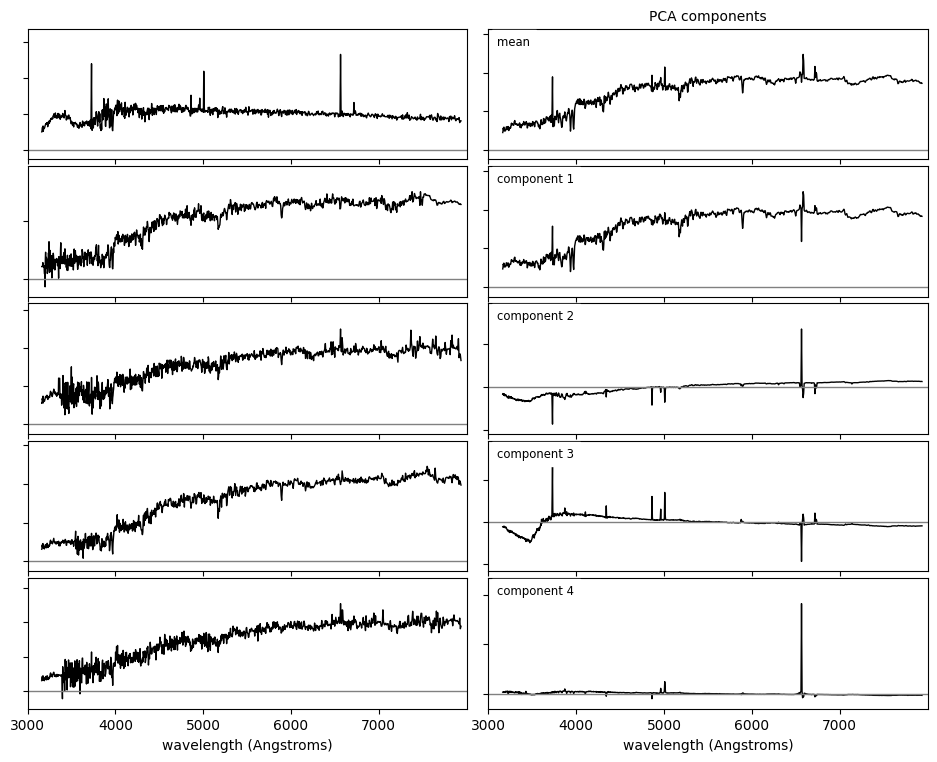

In [4]:
# Make plots
fig = plt.figure(figsize=(10, 8))
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.05,
                    bottom=0.1, top=0.95, hspace=0.05)

titles = 'PCA components'

for j in range(n_components):
    
    # plot the components
    ax = fig.add_subplot(n_components, 2, 2*j+2)
    ax.yaxis.set_major_formatter(plt.NullFormatter())
    ax.xaxis.set_major_locator(plt.MultipleLocator(1000))
    
    if j < n_components - 1:
        ax.xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax.set_xlabel('wavelength (Angstroms)')
    ax.plot(wavelengths, pca_comp[j], '-k', lw=1)

    # plot zero line
    xlim = [3000, 7999]
    ax.plot(xlim, [0, 0], '-', c='gray', lw=1)
    ax.set_xlim(xlim)

    # adjust y limits
    ylim = plt.ylim()
    dy = 0.05 * (ylim[1] - ylim[0])    
    ax.set_ylim(ylim[0] - dy, ylim[1] + 4 * dy)

    # plot the first j spectra
    ax2 = fig.add_subplot(n_components, 2, 2*j+1)
    ax2.yaxis.set_major_formatter(plt.NullFormatter())
    ax2.xaxis.set_major_locator(plt.MultipleLocator(1000))
    if j < n_components - 1:
        ax2.xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax2.set_xlabel('wavelength (Angstroms)')
    ax2.plot(wavelengths, spectra[j], '-k', lw=1)
    
    # plot zero line
    ax2.plot(xlim, [0, 0], '-', c='gray', lw=1)
    ax2.set_xlim(xlim)

    if j == 0:
        ax.set_title(titles, fontsize='medium')
    if j == 0:
        label = 'mean'
    else:
        label = 'component %i' % j

    # adjust y limits
    ylim = plt.ylim()
    dy = 0.05 * (ylim[1] - ylim[0])    
    ax2.set_ylim(ylim[0] - dy, ylim[1] + 4 * dy)

    ax.text(0.02, 0.95, label, transform=ax.transAxes,
            ha='left', va='top', bbox=dict(ec='w', fc='w'),
            fontsize='small')

plt.show()

Let us make a scree plot which tells us the amount of variance that is explained as a function of each eigenvector.

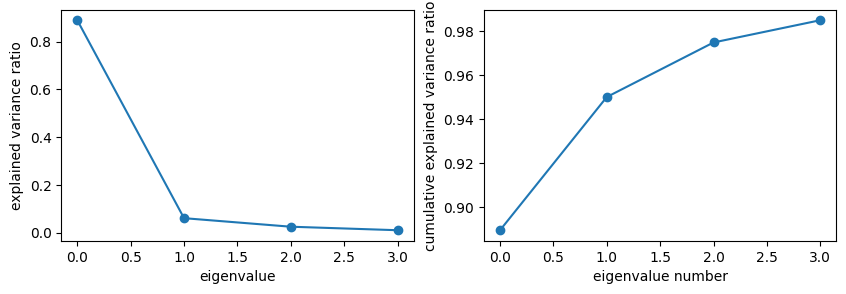

In [5]:
# Execute this cell
import numpy as np
from matplotlib import pyplot as plt

#----------------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(121)

ax.plot(np.arange(n_components-1), evals)
ax.scatter(np.arange(n_components-1), evals)

ax.set_xlabel("eigenvalue")
ax.set_ylabel("explained variance ratio")

ax = fig.add_subplot(122)

ax.plot(np.arange(n_components-1), evals.cumsum())
ax.scatter(np.arange(n_components-1), evals.cumsum())

ax.set_xlabel("eigenvalue number")
ax.set_ylabel("cumulative explained variance ratio")

plt.show()

In [6]:
print("The first component explains {:.3f} of the variance in the data.".format(pca.explained_variance_ratio_[0]))
print("The second component explains {:.3f} of the variance in the data.".format(pca.explained_variance_ratio_[1]))
#print("All components explain {:.3f} of the variance in the data.".format(sum(pca.explained_variance_ratio_)))

The first component explains 0.889 of the variance in the data.
The second component explains 0.061 of the variance in the data.


We can ask ourselves a question like, how many components would be required to explain 99.5% of the variance?

In [7]:
for num_feats in np.arange(1,20, dtype = int):
    pca = PCA(n_components=num_feats)
    pca.fit(spectra[ind])
    if (sum(pca.explained_variance_ratio_)>0.995):
        break
print("{:d} features are needed to explain 99.5% of the variance".format(num_feats))


# OR we can do an easier method

pca995 = PCA(n_components=0.995)
pca995.fit(spectra[ind])
print("{:d} features are needed to explain 99.5% of the variance".format(pca995.n_components_))


8 features are needed to explain 99.5% of the variance
8 features are needed to explain 99.5% of the variance


Once we have eigenvectors, we can reconstruct an observed spectrum, $x(k)$, from the mean plus a weighted sum of the eigenspectra:

$$
x_i(k)=\mu(k)+\sum_j^R \theta_{ij}e_j(k)
$$

Where $\mu(k)$ is the mean spectrum, $e_j(k)$ is the eigenspectrum $j$. $\theta_{ij}$ tells you how much of eigenspectrum $j$ is needed for spectrum $i$

The full equation gives the full reconstruction of the data, but if we truncate ($r < R$), then we will have reduced the dimensionality while still reconstructing the data with relatively little loss of information.

This works as PC1 explains the most variance, then PC2 and PC3, etc. So if the first few PC's have captured most of the variance, the later components add relatively little. This is known as dimensionality reduction.



(4000, 1000) (1000,)
(1000, 1000)
(1000,)
(1000,)
(1000,)
(1000,)


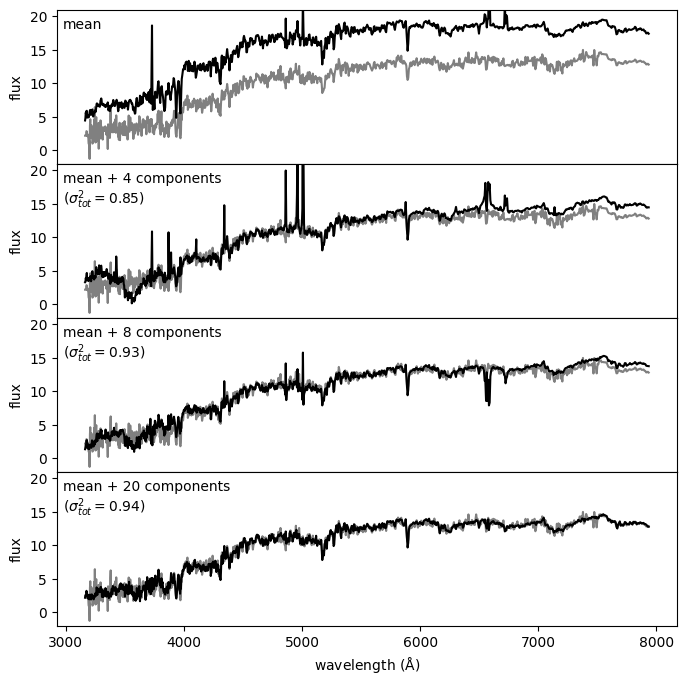

In [8]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from astroML.datasets import sdss_corrected_spectra



data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = sdss_corrected_spectra.compute_wavelengths(data)

print(spectra.shape, wavelengths.shape)

# pca = PCA()
# pca.fit(spectra)
# evals = pca.explained_variance_ratio_
# evals_cs = evals.cumsum()

evals = data['evals'] ** 2
evals_cs = evals.cumsum()
evals_cs /= evals_cs[-1] # Normalise it such that adding them all up gives 1

evecs = data['evecs'] # these are the PC's

spec_mean = spectra.mean(axis = 0)
print(evecs.shape)
print(spec_mean.shape)

spec = spectra[1]
coeff = np.dot(evecs, spec - spec_mean)

print(spec_mean.shape)
print(spec.shape)
print(coeff.shape)

fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(hspace=0)

for i, n in enumerate([0, 4, 8, 20]):
    ax = fig.add_subplot(411 + i)

    # True spectrum
    ax.plot(wavelengths, spec, '-', c='gray')

    # PCA reconstruction
    reconstruction = spec_mean + np.dot(coeff[:n], evecs[:n])
    ax.plot(wavelengths, reconstruction, '-k')

    if i < 3:
        ax.xaxis.set_major_formatter(plt.NullFormatter())

    ax.set_ylim(-2, 21)
    ax.set_ylabel('flux')

    if n == 0:
        text = "mean"
    else:
        text = f"mean + {n} components\n"
        text += r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]

    ax.text(
        0.01, 0.95, text,
        ha='left', va='top',
        transform=ax.transAxes
    )

fig.axes[-1].set_xlabel(r'${\rm wavelength\ (\AA)}$')
plt.show()


PCA is a linear process, while the variation may not be. Hence we may need a large number of components to fully describe any non-linearity.
It can also be very impractical for large data sets as the memory could be exceeded.

The amount of components you keep can be found through cross validation. We can use the scree plot as a rule of thumb for where the curve becomes steep.


### What about missing data?

Often datasets are incomplete, once we have 2 PCA's, we can estimate missing data by iteratively projecting incomplete data onto the principal components and filling in missing values until convergence.

It does this by:
1. Start by filling missing entries with initial guesses like the mean or 0
2. Compute PCA on the current data matrix to find the principal components
3. Replace the missing entries with the values that were reconstructed from the lower rank PCA approximation and repeat the process until the values stop changing

An example is shown below.

- Here, black are the observed spectra.
- Gray are the regions where we have no data.
- Blue is the PCA reconstruction, including the regions where there are no data.



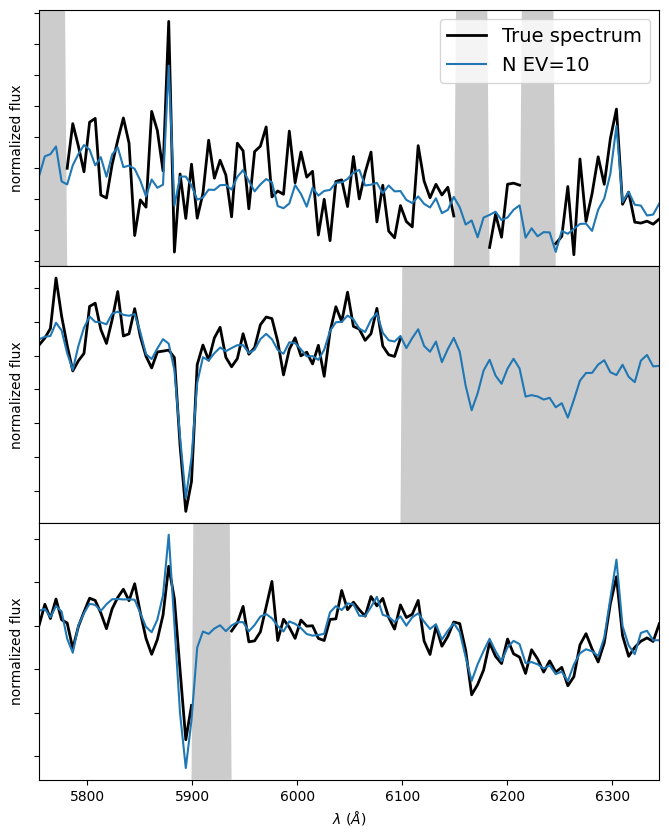

In [9]:
# Execute this cell
from matplotlib import ticker

from astroML.datasets import fetch_sdss_corrected_spectra
from astroML.datasets import sdss_corrected_spectra

#------------------------------------------------------------
# Get spectra and eigenvectors used to reconstruct them
data = fetch_sdss_corrected_spectra()
spec = sdss_corrected_spectra.reconstruct_spectra(data)
lam = sdss_corrected_spectra.compute_wavelengths(data)
evecs = data['evecs']
mu = data['mu']
norms = data['norms']
mask = data['mask']

#------------------------------------------------------------
# plot the results
i_plot = ((lam > 5750) & (lam < 6350))
lam = lam[i_plot]

specnums = [20, 8, 9]
subplots = [311, 312, 313]

fig = plt.figure(figsize=(8, 10))
fig.subplots_adjust(hspace=0)

for subplot, i in zip(subplots, specnums):
    ax = fig.add_subplot(subplot)

    # compute eigen-coefficients
    spec_i_centered = spec[i] / norms[i] - mu
    coeffs = np.dot(spec_i_centered, evecs.T)

    # blank out masked regions
    spec_i = spec[i]
    mask_i = mask[i]
    spec_i[mask_i] = np.nan

    # plot the raw masked spectrum
    ax.plot(lam, spec_i[i_plot], '-', color='k', lw=2,
            label='True spectrum')

    # plot reconstruction
    for nev in [10]:
        if nev == 0:
            label = 'mean'
        else:
            label = 'N EV=%i' % nev
        spec_i_recons = norms[i] * (mu + np.dot(coeffs[:nev], evecs[:nev]))
        ax.plot(lam, spec_i_recons[i_plot], label=label)

    # plot shaded background in masked region
    ylim = ax.get_ylim()
    mask_shade = ylim[0] + mask[i][i_plot].astype(float) * ylim[1]
    plt.fill(np.concatenate([lam[:1], lam, lam[-1:]]),
             np.concatenate([[ylim[0]], mask_shade, [ylim[0]]]),
             lw=0, fc='k', alpha=0.2)

    ax.set_xlim(lam[0], lam[-1])
    ax.set_ylim(ylim)
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

    if subplot == 311:
        ax.legend(loc=1, prop=dict(size=14))

    ax.set_xlabel('$\lambda\ (\AA)$')
    ax.set_ylabel('normalized flux')

plt.show()

### Non Negative Matrix Factorisation


One of the biggest drawbacks of PCA is that eigenvectors are defined relative to the mean data vector. This results in PC's that can be +ve or -ve. For many physical systems, the data can be reoresented as a linear sum of positive components.



Figures taken from [here - Ahmad Varasteh](https://www.youtube.com/watch?v=o4pPTwsd-5M)

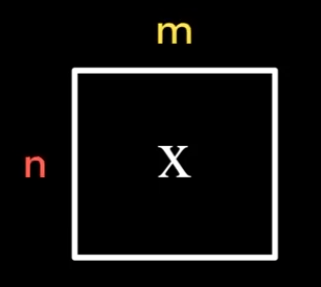

Imagine we have a matrix of $n \times m$, non negative in the case that it has no negative entries.

We want to factorise this matrix into two non negative matrices:

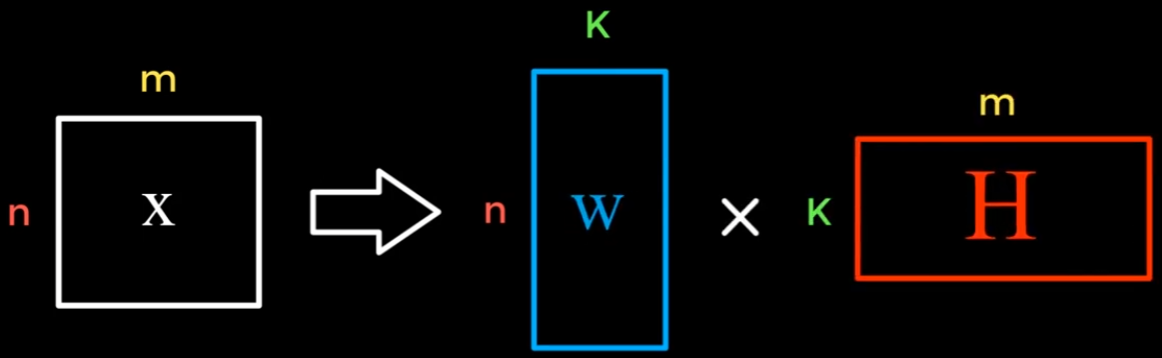

To do this, we need to solve a minimisation problem, where we minimise the distance between $X$ and $W \times H$

This can only be found numerically.

An implementation of this in scikitlearn looks like this:

In [10]:
# Execute this cell
from sklearn.decomposition import NMF

X = np.random.random((100,10)) # 100 points in 10-D, all +ve
nmf = NMF(n_components=3)
nmf.fit(X)

W = nmf.transform(X) # project to 3 dimension
Y = nmf.components_ # 3x10 array of components
err = nmf.reconstruction_err_ # how well 3 components capture the data

#print(W)
#print(Y)
print(err)

7.037186107676697


C:\Users\krist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


## CODING PRACTICE

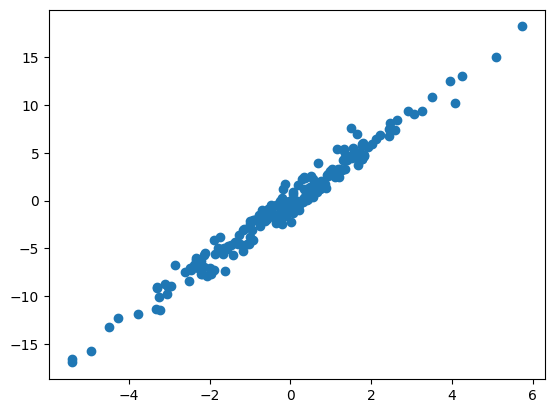

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

rng = np.random.default_rng(1)

x = rng.normal(0, 2, 200)
y = 3*x + rng.normal(0, 1, 200)

X = np.column_stack([x, y])

plt.scatter(X[:, 0], X[:, 1])

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(pca.components_) # direction the new PC axes point int

print(pca.explained_variance_ratio_)    # How much variance each direction captures


[[ 0.30791163  0.95141496]
 [ 0.95141496 -0.30791163]]
[0.9978114 0.0021886]


In [16]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

import pandas as pd
df_stars = pd.read_csv("stars.csv")

df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [20]:
features = [
    "Temperature (K)",
    "Luminosity(L/Lo)",
    "Radius(R/Ro)",
    "Absolute magnitude(Mv)"
]

X_stars = df_stars[features].values

print(X_stars.shape)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_stars)

print(pca.explained_variance_ratio_)

(240, 4)
[9.97606313e-01 2.38789920e-03 5.78677260e-06 1.34274189e-09]


When we plot this, we expect the PC1 to be dominated by luminosity as PC1 explains about 99% of the data.

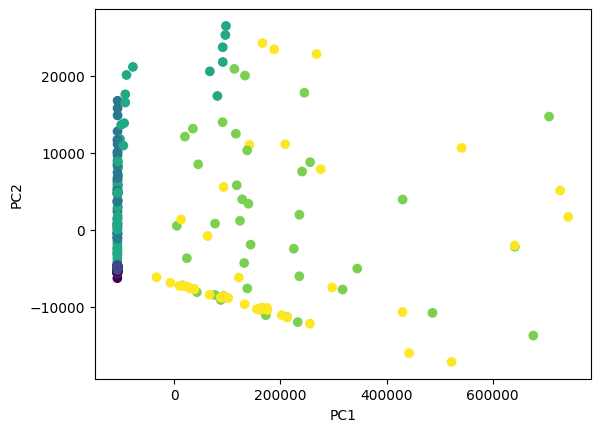

In [24]:
star_type_num, star_type_names = pd.factorize(df_stars["Star type"])

plt.scatter(X_pca[:, 0],X_pca[:, 1],c=star_type_num)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Let us go to our standardising friend!

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_stars)

print(X_scaled.mean(axis=0))
print(X_scaled.std(axis=0))

[-1.48029737e-17  2.96059473e-17 -1.57281595e-17 -3.88578059e-17]
[1. 1. 1. 1.]


We have means that are approximately 0 and std that are 1.

In [26]:
pca_scaled = PCA(n_components=4)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

print(pca_scaled.explained_variance_ratio_)

[0.60357391 0.23500784 0.09329645 0.0681218 ]


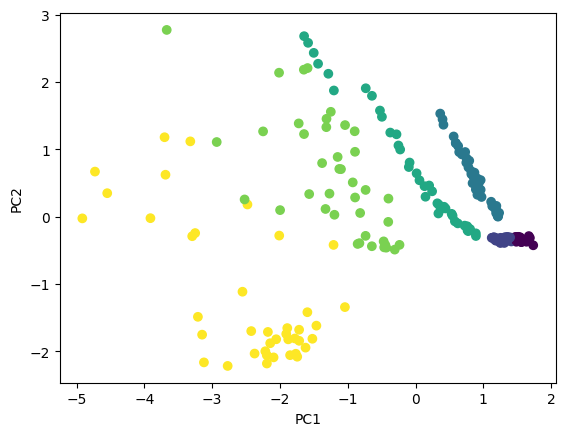

In [27]:
plt.scatter(X_pca_scaled[:, 0],X_pca_scaled[:, 1],c=star_type_num)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

We are seeing about 84% of the variance here, scaling down from 4 features.

In [28]:
for i, component in enumerate(pca_scaled.components_[:2]):
    print(f"PC{i+1}")
    
    for feature, loading in zip(features, component):
        print(feature, loading)
        
    print()

PC1
Temperature (K) -0.3501834268174357
Luminosity(L/Lo) -0.5593378877324204
Radius(R/Ro) -0.47477106986887485
Absolute magnitude(Mv) 0.582327335907388

PC2
Temperature (K) 0.821612622507167
Luminosity(L/Lo) 0.0045256354196469145
Radius(R/Ro) -0.5689811496380729
Absolute magnitude(Mv) 0.03453503319068071



This looks much better!